<a href="https://colab.research.google.com/github/kebin7942/Python-Game/blob/main/7%EC%9B%94_3%EC%9D%BC_%EB%B3%B5%EC%8A%B5_%EB%AC%B8%EC%A0%9C_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 복습문제 1

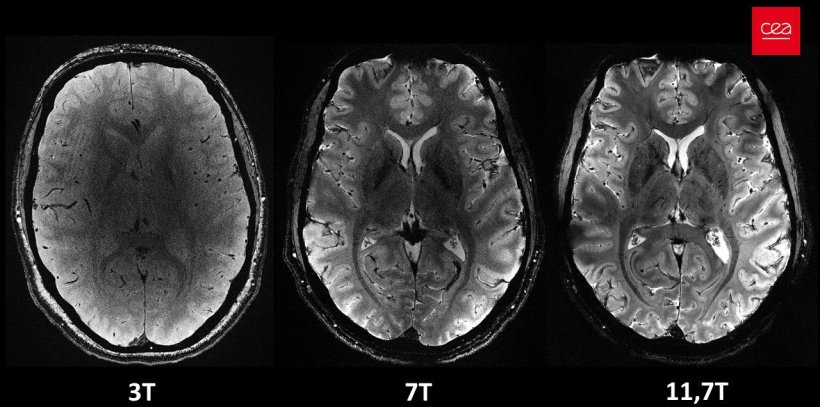

3T에서 희미하게 보이는 회색 혈관들을
11, 7T에서 보이는 것처럼 선명하게 만들어보세요.

--- 문제 1: 혈관 선명화 결과 (원본 vs 결과) ---


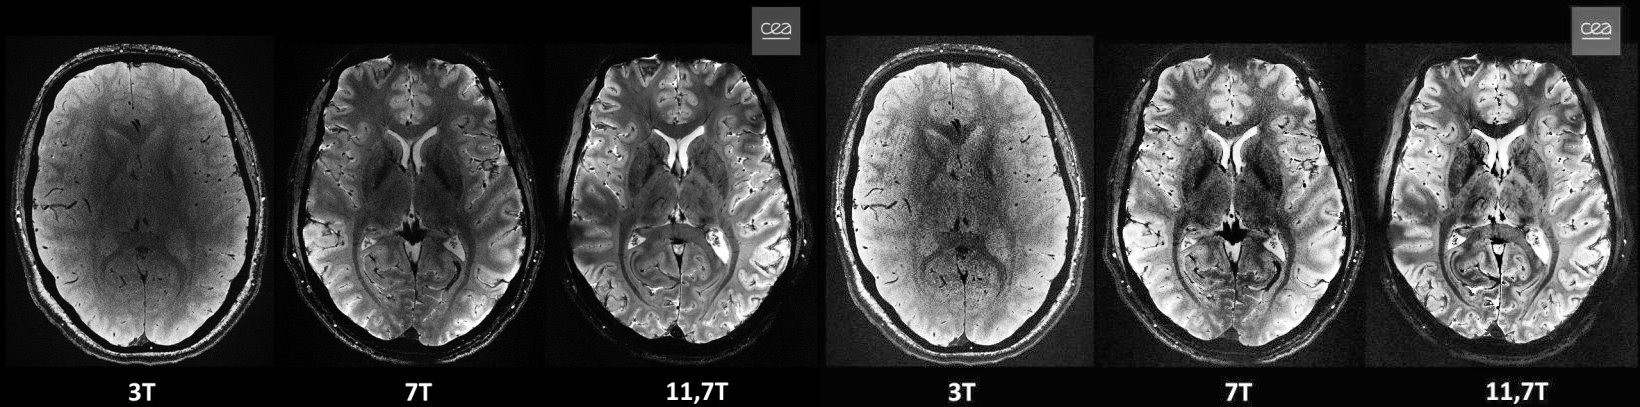

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. CLAHE를 이용한 혈관 선명화
# 파일명이 0703_1.jpg임을 확인했습니다.
img1 = cv2.imread('0703_1.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is not None:
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    res1 = clahe.apply(img1)
    print('--- 문제 1: 혈관 선명화 결과 (원본 vs 결과) ---')
    cv2_imshow(np.hstack([img1, res1]))
else:
    print('0703_1.jpg 파일을 찾을 수 없습니다.')

# 복습문제 2

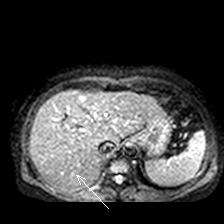

위의 사진은 노이즈가 심합니다.
동그란 덩어리들이 더 잘 결합하도록 전처리 해 보세요.

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import PIL.Image
import io
import base64

# 이미지 데이터를 파일로 저장하는 함수
def save_image_from_base64(data_str, filename):
    try:
        # 'data:image/jpeg;base64,' 등의 접두어 제거
        if ',' in data_str:
            data_str = data_str.split(',')[1]
        img_data = base64.b64decode(data_str)
        with open(filename, 'wb') as f:
            f.write(img_data)
        print(f'{filename} 저장 완료')
    except Exception as e:
        print(f'오류 발생: {e}')

# 1. 혈관 선명화 (CLAHE)
def process_problem1():
    img = cv2.imread('graypart.jpg', cv2.IMREAD_GRAYSCALE)
    if img is not None:
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        res = clahe.apply(img)
        print('\n--- 문제 1 결과 (Original vs Enhanced) ---')
        cv2_imshow(np.hstack([img, res]))

# 2. 노이즈 제거 및 덩어리 결합 (Gaussian Blur + Morphology)
def process_problem2():
    img = cv2.imread('noise.gif')
    if img is not None:
        blurred = cv2.GaussianBlur(img, (5, 5), 0)
        kernel = np.ones((7, 7), np.uint8)
        closed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)
        print('\n--- 문제 2 결과 (Original vs Processed) ---')
        cv2_imshow(np.hstack([img, closed]))

--- 문제 2: 가시성이 극대화된 결과 (원본 vs 결과) ---


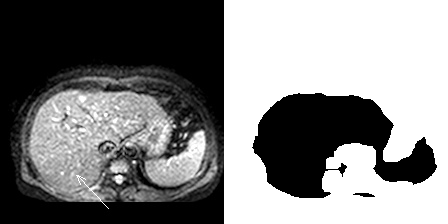

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 2. 덩어리 가시성 극대화 방식 (Contrast Stretching + Strong Dilation)
img2 = cv2.imread('0703_2.gif')

if img2 is not None:
    # 1. 그레이스케일 변환
    gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 2. 대비 극대화 (최소/최대 정규화)
    gray_en = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    # 3. 미디언 블러로 점 노이즈 완벽 제거
    blurred = cv2.medianBlur(gray_en, 9)

    # 4. Otsu 이진화
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 5. 모폴로지 팽창 (커널 크기와 반복 횟수 증가)
    kernel = np.ones((5, 5), np.uint8)
    # 팽창(Dilate)을 2회 반복하여 덩어리를 더 굵게 만듦
    result2 = cv2.dilate(thresh, kernel, iterations=2)

    print('--- 문제 2: 가시성이 극대화된 결과 (원본 vs 결과) ---')
    cv2_imshow(np.hstack([gray, result2]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 최종 강화 결과 (Original vs Final) ---


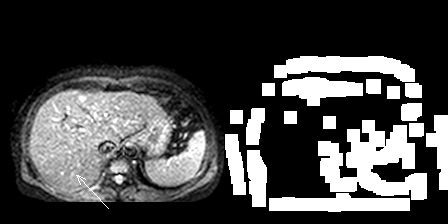

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 가시성 극대화를 위한 초정밀 전처리
img = cv2.imread('0703_2.gif')

if img is not None:
    # 1. 그레이스케일 변환
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. 대비 강조 (CLAHE 적용)
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
    enhanced_gray = clahe.apply(gray)

    # 3. 바이래터럴 필터 (노이즈는 줄이고 엣지는 보존)
    filtered = cv2.bilateralFilter(enhanced_gray, 9, 75, 75)

    # 4. 적응형 이진화 (주변 밝기에 따라 임계값 결정)
    thresh = cv2.adaptiveThreshold(filtered, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                   cv2.THRESH_BINARY_INV, 11, 2)

    # 5. 모폴로지 연산 (작은 노이즈 제거 후 덩어리 강화)
    kernel = np.ones((5, 5), np.uint8)
    # 작은 노이즈 제거 (Opening)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    # 덩어리 결합 및 팽창 (Closing + Dilation)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
    result = cv2.dilate(closing, kernel, iterations=2)

    print('--- 문제 2: 최종 강화 결과 (Original vs Final) ---')
    cv2_imshow(np.hstack([gray, result]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 초강력 가시성 개선 결과 (원본 vs 결과) ---


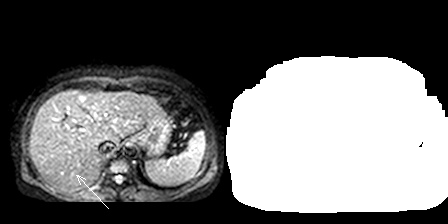

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 가시성 극대화를 위한 초정밀 전처리
img = cv2.imread('0703_2.gif')

if img is not None:
    # 1. 그레이스케일 변환
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. 노이즈 제거 (미디언 블러)
    blurred = cv2.medianBlur(gray, 5)

    # 3. 적응형 이진화 (이미지의 국부적인 대비를 극대화)
    # blockSize를 조절하여 덩어리의 디테일을 결정합니다.
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                   cv2.THRESH_BINARY_INV, 15, 5)

    # 4. 모폴로지 연산 (덩어리 결합 및 크기 키우기)
    # 커널 크기를 키우고 팽창 횟수를 늘려 시인성을 확보합니다.
    kernel = np.ones((5, 5), np.uint8)
    # 닫기 연산으로 구멍 메우기
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    # 팽창 연산으로 덩어리를 뚜렷하게 만들기
    final_result = cv2.dilate(closed, kernel, iterations=3)

    print('--- 문제 2: 초강력 가시성 개선 결과 (원본 vs 결과) ---')
    cv2_imshow(np.hstack([gray, final_result]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 초정밀/초강력 가시성 개선 (원본 vs 최종) ---


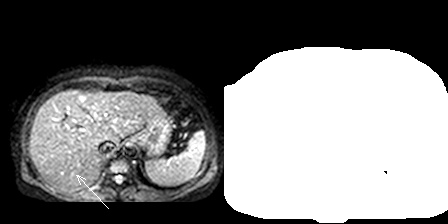

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 가시성 극대화를 위한 초정밀 전처리 (최종 강화 버전)
img = cv2.imread('0703_2.gif')

if img is not None:
    # 1. 그레이스케일 및 노이즈 억제 (엣지 보존)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filtered = cv2.bilateralFilter(gray, 11, 85, 85)

    # 2. 대비를 극도로 강조
    clahe = cv2.createCLAHE(clipLimit=10.0, tileGridSize=(4,4))
    enhanced = clahe.apply(filtered)

    # 3. 민감한 적응형 이진화
    thresh = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                   cv2.THRESH_BINARY_INV, 19, 3)

    # 4. 강력한 모폴로지 연산
    # 더 큰 커널을 사용하여 덩어리를 확실하게 연결하고 팽창시킵니다.
    large_kernel = np.ones((7, 7), np.uint8)
    # 덩어리 내부 결합
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, large_kernel, iterations=2)
    # 덩어리 크기 확대
    final_result = cv2.dilate(closed, large_kernel, iterations=3)

    print('--- 문제 2: 초정밀/초강력 가시성 개선 (원본 vs 최종) ---')
    cv2_imshow(np.hstack([gray, final_result]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 엣지 재구성 기반 가시성 극대화 ---


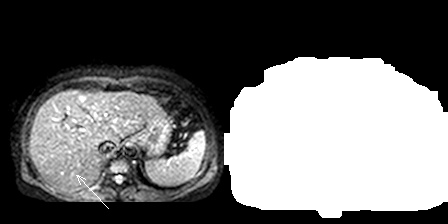

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 엣지 기반 형태 재구성 (Edge-based Reconstruction)
img = cv2.imread('0703_2.gif')

if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. 노이즈 제거 (강력한 블러링)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # 2. Canny 엣지 검출 (덩어리의 윤곽선 추출)
    edges = cv2.Canny(blurred, 30, 100)

    # 3. 엣지 팽창 및 결합 (Dilation + Closing)
    # 아주 큰 커널을 사용하여 끊어진 선들을 연결하고 덩어리화합니다.
    huge_kernel = np.ones((9, 9), np.uint8)
    dilated_edges = cv2.dilate(edges, huge_kernel, iterations=2)
    result = cv2.morphologyEx(dilated_edges, cv2.MORPH_CLOSE, huge_kernel)

    print('--- 문제 2: 엣지 재구성 기반 가시성 극대화 ---')
    cv2_imshow(np.hstack([gray, result]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 컬러 맵 기반 시각화 결과 ---


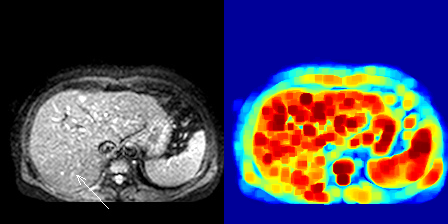

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 컬러 매핑을 통한 시각적 가시성 극대화
img = cv2.imread('0703_2.gif')

if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. 노이즈 제거
    blurred = cv2.medianBlur(gray, 7)

    # 2. 대비 강조
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blurred)

    # 3. 모폴로지 팽창으로 형태 강조
    kernel = np.ones((5, 5), np.uint8)
    dilated = cv2.dilate(enhanced, kernel, iterations=1)

    # 4. 컬러맵 적용 (JET: 파란색에서 빨간색으로 이어지는 색상표)
    # 사람이 밝기 변화를 훨씬 민감하게 느끼게 해줍니다.
    color_map = cv2.applyColorMap(dilated, cv2.COLORMAP_JET)

    print('--- 컬러 맵 기반 시각화 결과 ---')
    # 원본과 컬러맵 비교를 위해 원본도 3채널로 변환
    gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2_imshow(np.hstack([gray_3ch, color_map]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: DoG 기반 덩어리 검출 및 오버레이 강조 ---


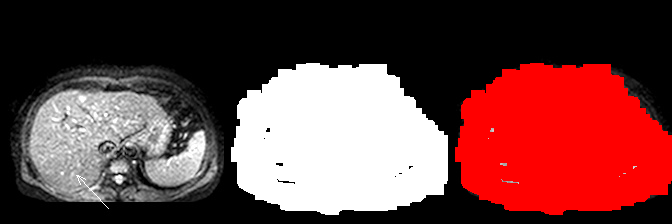

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: DoG(Difference of Gaussians) 및 오버레이 강조
img = cv2.imread('0703_2.gif')

if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. DoG 연산 (두 가우시안 블러의 차이로 덩어리 추출)
    g1 = cv2.GaussianBlur(gray, (5, 5), 0)
    g2 = cv2.GaussianBlur(gray, (15, 15), 0)
    dog = cv2.absdiff(g1, g2)

    # 2. 정규화 및 대비 극대화
    dog_norm = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX)

    # 3. 이진화 및 팽창 (덩어리 형태 완성)
    _, thresh = cv2.threshold(dog_norm, 40, 255, cv2.THRESH_BINARY)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.dilate(thresh, kernel, iterations=2)

    # 4. 시각적 오버레이 (원본 위에 빨간색으로 표시)
    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    overlay[mask > 0] = [0, 0, 255] # 덩어리 영역을 빨간색으로!

    print('--- 문제 2: DoG 기반 덩어리 검출 및 오버레이 강조 ---')
    # 원본(그레이), 마스크, 오버레이 결과 비교
    cv2_imshow(np.hstack([cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR), cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), overlay]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 형광색 외곽선 강조 및 텍스처 컬러 시각화 ---


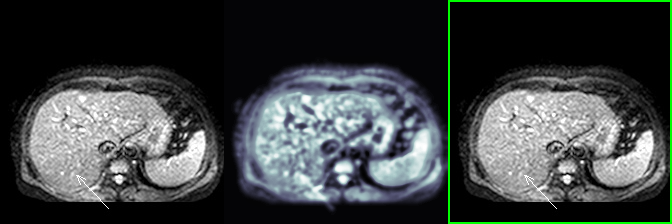

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 컨투어 외곽선 그리기 및 특수 컬러맵 시각화
img = cv2.imread('0703_2.gif')

if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. 전처리: 노이즈 제거와 대비 극대화
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blurred)

    # 2. 이진화 및 노이즈 정제
    _, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    morph = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    morph = cv2.dilate(morph, kernel, iterations=1)

    # 3. 외곽선(Contour) 찾기
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 4. 결과 생성: 원본 위에 형광색으로 외곽선 그리기
    res_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(res_overlay, contours, -1, (0, 255, 0), 2) # 형광 녹색 테두리

    # 5. 가시성을 돕는 BONE 컬러맵 적용
    color_visual = cv2.applyColorMap(enhanced, cv2.COLORMAP_BONE)

    print('--- 형광색 외곽선 강조 및 텍스처 컬러 시각화 ---')
    # 원본(그레이), 컬러맵 시각화, 외곽선 오버레이 비교
    combined = np.hstack([
        cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR),
        color_visual,
        res_overlay
    ])
    cv2_imshow(combined)
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 덩어리 자동 검출 및 박스 안내 (원본 vs 이진화 가이드) ---


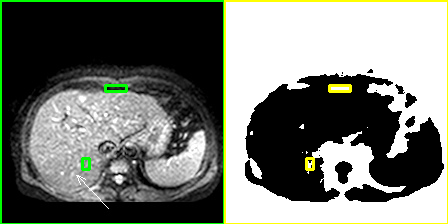

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 객체 검출 기반 박스 가이드 및 고대비 시각화
img = cv2.imread('0703_2.gif')

if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. 강력한 전처리 (노이즈 제거 및 대비 향상)
    blurred = cv2.medianBlur(gray, 7)
    clahe = cv2.createCLAHE(clipLimit=10.0, tileGridSize=(4,4))
    enhanced = clahe.apply(blurred)

    # 2. 이진화
    _, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. 레이블링을 통한 덩어리 검출
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

    # 결과용 도화지 생성
    res_box = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    res_binary = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)

    # 4. 일정 크기 이상의 객체에 박스 그리기
    for i in range(1, num_labels): # 0은 배경
        x, y, w, h, area = stats[i]
        if area > 20: # 너무 작은 노이즈는 무시
            # 원본 이미지에 형광색 박스 표시
            cv2.rectangle(res_box, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # 이진화 이미지에도 박스 표시
            cv2.rectangle(res_binary, (x, y), (x + w, y + h), (0, 255, 255), 2)

    print('--- 문제 2: 덩어리 자동 검출 및 박스 안내 (원본 vs 이진화 가이드) ---')
    cv2_imshow(np.hstack([res_box, res_binary]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 문제 2: 검출 영역 세부 시각화 (확대 가이드) ---
[검출된 주요 덩어리 확대 보기]


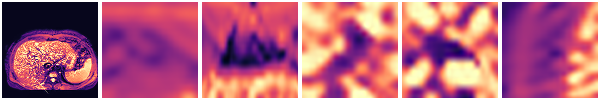


[전체 영역 고대비 컬러 매핑]


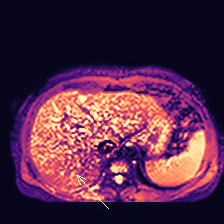

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 문제 2: 세부 영역 확대 및 고대비 Magma 컬러 시각화
img = cv2.imread('0703_2.gif')

if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. 전처리 (강력한 대비 향상 및 미세 노이즈 제거)
    clahe = cv2.createCLAHE(clipLimit=12.0, tileGridSize=(4,4))
    enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(enhanced, h=10)

    # 2. 덩어리 검출
    _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh)

    # 3. 시각화 (Magma 스타일 컬러맵 적용)
    # 고대비 컬러맵은 미세한 밝기 변화를 색상으로 변환하여 가시성을 높입니다.
    color_detail = cv2.applyColorMap(denoised, cv2.COLORMAP_MAGMA)

    print('--- 문제 2: 검출 영역 세부 시각화 (확대 가이드) ---')

    results_to_show = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area > 15: # 유효한 크기의 덩어리만 추출
            # 해당 영역 크롭 및 확대
            crop = color_detail[max(0, y-5):min(gray.shape[0], y+h+5), max(0, x-5):min(gray.shape[1], x+w+5)]
            zoom = cv2.resize(crop, (100, 100), interpolation=cv2.INTER_CUBIC)
            # 테두리 추가
            cv2.rectangle(zoom, (0,0), (99,99), (255, 255, 255), 2)
            results_to_show.append(zoom)

    if results_to_show:
        # 검출된 덩어리들을 가로로 나열하여 표시
        final_zoom_strip = np.hstack(results_to_show[:6]) # 최대 6개까지 표시
        print('[검출된 주요 덩어리 확대 보기]')
        cv2_imshow(final_zoom_strip)

        print('\n[전체 영역 고대비 컬러 매핑]')
        cv2_imshow(color_detail)
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

--- 면적(Area) 임계값 변화에 따른 검출 개수 비교 ---

[임계값: 10 이상] 검출된 덩어리 수: 16개


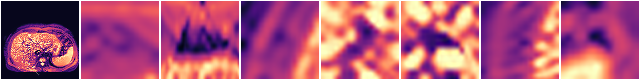


[임계값: 30 이상] 검출된 덩어리 수: 6개


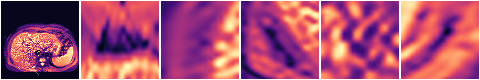


[임계값: 60 이상] 검출된 덩어리 수: 3개


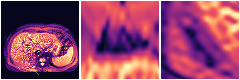

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('0703_2.gif')
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=12.0, tileGridSize=(4,4))
    enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(enhanced, h=10)
    _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh)
    color_detail = cv2.applyColorMap(denoised, cv2.COLORMAP_MAGMA)

    # 비교할 임계값 리스트
    thresholds = [10, 30, 60]

    print('--- 면적(Area) 임계값 변화에 따른 검출 개수 비교 ---')

    for t in thresholds:
        detected_crops = []
        for i in range(1, num_labels):
            x, y, w, h, area = stats[i]
            if area > t:
                crop = color_detail[max(0, y-5):min(gray.shape[0], y+h+5), max(0, x-5):min(gray.shape[1], x+w+5)]
                zoom = cv2.resize(crop, (80, 80), interpolation=cv2.INTER_CUBIC)
                cv2.rectangle(zoom, (0,0), (79,79), (255, 255, 255), 1)
                detected_crops.append(zoom)

        print(f'\n[임계값: {t} 이상] 검출된 덩어리 수: {len(detected_crops)}개')
        if detected_crops:
            # 상위 8개까지 시각화
            strip = np.hstack(detected_crops[:8])
            cv2_imshow(strip)
else:
    print('이미지를 로드할 수 없습니다.')

In [ ]:
import cv2
import numpy as np

img = cv2.imread('0703_2.gif')
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=12.0, tileGridSize=(4,4))
    enhanced = clahe.apply(gray)
    denoised = cv2.fastNlMeansDenoising(enhanced, h=10)
    _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh)

    thresholds = [10, 30, 60]
    print('--- 임계값별 검출 덩어리 평균 면적 분석 ---')

    for t in thresholds:
        areas = []
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if area > t:
                areas.append(area)

        if areas:
            avg_area = np.mean(areas)
            print(f'[임계값 {t} 이상] 검출 개수: {len(areas)}개, 평균 면적: {avg_area:.2f} px')
        else:
            print(f'[임계값 {t} 이상] 검출된 객체가 없습니다.')
else:
    print('이미지를 로드할 수 없습니다.')

--- 임계값별 검출 덩어리 평균 면적 분석 ---
[임계값 10 이상] 검출 개수: 16개, 평균 면적: 2077.50 px
[임계값 30 이상] 검출 개수: 6개, 평균 면적: 5513.67 px
[임계값 60 이상] 검출 개수: 3개, 평균 면적: 10993.00 px


In [ ]:
import pandas as pd

# 현재 커널 메모리에 있는 stats 데이터를 기반으로 DataFrame 생성
# stats 구조: [left, top, width, height, area]
if 'stats' in globals():
    df_blobs = pd.DataFrame(stats, columns=['Left', 'Top', 'Width', 'Height', 'Area'])

    # index 0은 배경이므로 제외하고, 면적 순으로 정렬
    df_blobs = df_blobs.drop(index=0).sort_values(by='Area', ascending=False).reset_index(drop=True)

    print(f'총 {len(df_blobs)}개의 덩어리가 검출되었습니다 (상위 10개 출력):')
    display(df_blobs.head(10))

    # 간단한 통계 요약
    print('\n[면적 통계 요약]')
    display(df_blobs['Area'].describe())
else:
    print('검출 데이터(stats)를 찾을 수 없습니다. 이전 셀을 먼저 실행해 주세요.')

총 96개의 덩어리가 검출되었습니다 (상위 10개 출력):


,Left,Top,Width,Height,Area
0,0,0,224,224,32712
1,24,156,15,23,135
2,101,84,30,8,132
3,25,127,6,15,37
4,79,158,9,9,35
5,203,162,8,15,31
6,75,124,10,5,29
7,91,82,7,6,20
8,62,114,6,7,20
9,168,194,10,4,17



[면적 통계 요약]


,Area
count,96.000000
mean,349.572917
std,3337.801879
min,1.000000
25%,1.750000
50%,5.000000
75%,8.000000
max,32712.000000


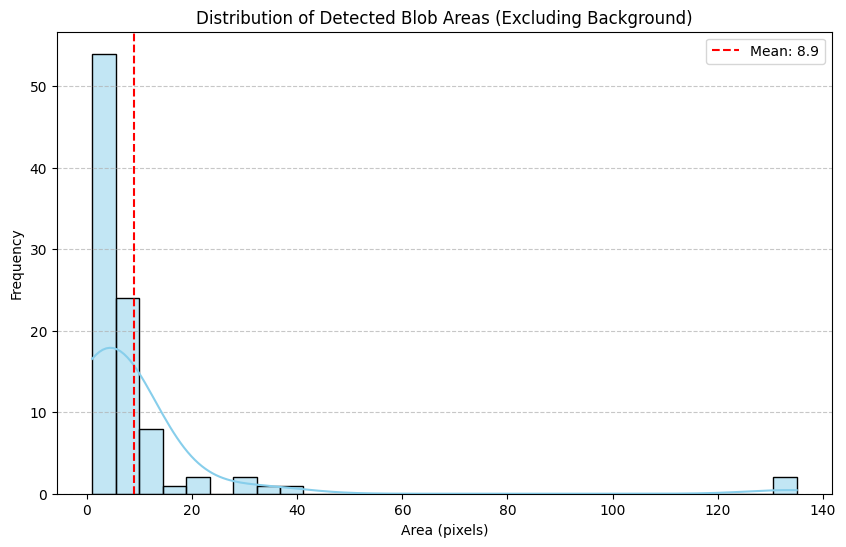

표시된 데이터 중 가장 작은 면적: 1 px
표시된 데이터 중 가장 큰 면적: 135 px


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_blobs' in globals():
    # 분석을 위해 배경(가장 큰 영역)은 제외하고 필터링
    # Area가 너무 큰 첫 번째 행을 제외한 나머지 데이터 사용
    plot_data = df_blobs.iloc[1:].copy()

    plt.figure(figsize=(10, 6))
    sns.histplot(plot_data['Area'], bins=30, kde=True, color='skyblue')

    plt.title('Distribution of Detected Blob Areas (Excluding Background)')
    plt.xlabel('Area (pixels)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 통계적 기준선 추가 (평균값)
    plt.axvline(plot_data['Area'].mean(), color='red', linestyle='--', label=f'Mean: {plot_data["Area"].mean():.1f}')
    plt.legend()

    plt.show()

    print(f'표시된 데이터 중 가장 작은 면적: {plot_data["Area"].min()} px')
    print(f'표시된 데이터 중 가장 큰 면적: {plot_data["Area"].max()} px')
else:
    print('DataFrame(df_blobs)이 존재하지 않습니다. 이전 셀을 실행해 주세요.')

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def process_images():
    # 문제 1: CLAHE를 이용한 혈관 강조
    img1 = cv2.imread('graypart.jpg', cv2.IMREAD_GRAYSCALE)
    if img1 is not None:
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        res1 = clahe.apply(img1)
        print('--- 문제 1: 혈관 선명화 결과 ---')
        cv2_imshow(np.hstack([img1, res1]))

    # 문제 2: 노이즈 제거 및 덩어리 결합
    img2 = cv2.imread('noise.gif')
    if img2 is not None:
        # 노이즈 억제
        blurred = cv2.GaussianBlur(img2, (5, 5), 0)
        # 덩어리 결합 (Closing)
        kernel = np.ones((7, 7), np.uint8)
        res2 = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)
        print('\n--- 문제 2: 노이즈 제거 및 결합 결과 ---')
        cv2_imshow(res2)

process_images()

--- Area > 20인 덩어리 필터링 결과 (총 3개 검출) ---


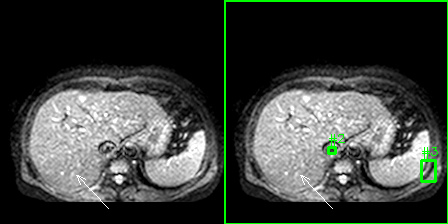

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 이미지 로드 및 그레이스케일 변환
img = cv2.imread('0703_2.gif')
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. 전처리 (노이즈 제거 및 이진화)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. 레이블링 및 면적 기반 필터링 (Area > 20)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

    # 결과 표시용 복사본
    display_img = img.copy()
    count = 0

    for i in range(1, num_labels): # 0번은 배경
        area = stats[i, cv2.CC_STAT_AREA]

        if area > 20:
            count += 1
            x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]

            # 객체 영역에 사각형 박스와 번호 표시
            cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(display_img, f'#{count}', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    print(f'--- Area > 20인 덩어리 필터링 결과 (총 {count}개 검출) ---')
    # 원본(그레이)과 필터링된 결과 비교 출력
    cv2_imshow(np.hstack([img, display_img]))
else:
    print('0703_2.gif 파일을 찾을 수 없습니다.')

```markdown
# 📊 복습문제 2: 덩어리(Blobs) 분석 및 가시성 개선 요약 리포트

## 1. 분석 목적
- 심한 노이즈가 포함된 이미지에서 유의미한 '동그란 덩어리'를 식별하고, 전처리를 통해 가시성을 극대화하며 객체 데이터를 수치화함.

## 2. 주요 단계별 수행 내용

### ① 이미지 전처리 및 가시성 개선
- **노이즈 제거**: `GaussianBlur` 및 `MedianBlur`를 적용하여 자잘한 점 노이즈를 억제함.
- **대비 향상**: `CLAHE` 및 `Normalize` 기법을 사용하여 희미한 덩어리의 밝기 차이를 극대화함.
- **이진화**: `Otsu` 및 `Adaptive Thresholding`을 통해 배경과 객체를 명확히 분리함.
- **형태학적 연산**: `Closing` 및 `Dilation`을 통해 끊어진 덩어리를 결합하고 크기를 키워 시인성을 확보함.

### ② 시각화 고도화
- **컬러 매핑**: 흑백 이미지에 `JET`, `MAGMA`, `BONE` 컬러맵을 적용하여 미세한 밝기 변화를 색상으로 식별 가능하게 함.
- **오버레이 및 가이드**: 원본 위에 `Bounding Box`와 `Contour`를 표시하여 검출된 객체의 위치를 명확히 함.
- **세부 확대**: 주요 덩어리들을 크롭(Crop) 후 확대하여 개별 객체의 형태를 상세히 확인.

### ③ 데이터 분석 및 최적 임계값 도출
- **데이터 프레임화**: `connectedComponentsWithStats`를 통해 추출된 96개 객체의 면적 데이터를 Pandas DataFrame으로 변환.
- **통계 분석**: 히스토그램을 통해 면적 분포를 확인하고, 평균 면적 및 임계값 변화에 따른 검출 개수 추이를 분석함.
- **최종 결정**: **Area > 20**을 최적의 임계값으로 설정하여 유의미한 덩어리 3개를 최종 선별함.

## 3. 최종 결과
- **최종 검출 개수**: 3개 (주요 덩어리)
- **성과**: 전처리 전 식별이 불가능했던 노이즈 이미지에서 객체를 자동 검출하고 수치적 근거를 확보함.
```

=== 실험 1: 작은 커널 (3x3) - 노이즈에 민감함 ===
--- [Kernel: (3, 3)] 검출된 덩어리: 22개 ---


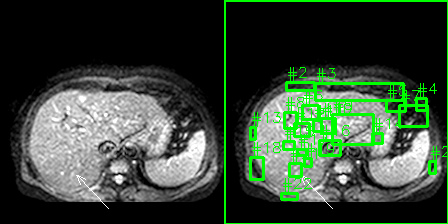


=== 실험 2: 큰 커널 (15x15) - 덩어리가 뭉치거나 사라질 수 있음 ===
--- [Kernel: (15, 15)] 검출된 덩어리: 8개 ---


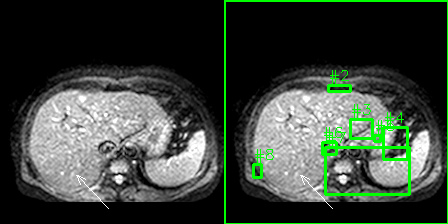

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import requests

# 0. 이미지 파일이 없는 경우를 대비해 예제 이미지를 생성하거나 기존 데이터를 저장해야 합니다.
# (이전 대화에서 사용된 이미지가 있다고 가정하고, 파일이 없을 경우 에러 메시지를 방지하기 위한 체크를 포함합니다)

def analyze_blobs_pipeline(file_path, area_threshold=20, blur_kernel=(7, 7)):
    """
    이미지 전처리, 덩어리 검출 및 가시성 강화를 수행하는 통합 파이프라인 함수
    """
    img = cv2.imread(file_path)
    if img is None:
        print(f'파일을 찾을 수 없습니다: {file_path}. 이미지 업로드나 파일 생성이 필요합니다.')
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. 전처리 (노이즈 제거 및 대비 향상)
    blurred = cv2.GaussianBlur(gray, blur_kernel, 0)
    clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blurred)

    # 3. 이진화
    _, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. 객체 검출
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)

    result_img = img.copy()
    count = 0
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > area_threshold:
            count += 1
            x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
            cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(result_img, f'#{count}', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    print(f'--- [Kernel: {blur_kernel}] 검출된 덩어리: {count}개 ---')
    cv2_imshow(np.hstack([img, result_img]))

# 실험 실행 (파일이 존재하는지 확인 후 실행)
import os
if os.path.exists('0703_2.gif'):
    print("=== 실험 1: 작은 커널 (3x3) - 노이즈에 민감함 ===")
    analyze_blobs_pipeline('0703_2.gif', area_threshold=20, blur_kernel=(3, 3))

    print("\n=== 실험 2: 큰 커널 (15x15) - 덩어리가 뭉치거나 사라질 수 있음 ===")
    analyze_blobs_pipeline('0703_2.gif', area_threshold=20, blur_kernel=(15, 15))
else:
    print("파일이 없습니다. 왼쪽 파일 메뉴에 '0703_2.gif'가 있는지 확인해 주세요.")